In [1]:
using Pkg
Pkg.activate(".")

  Activating 

project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [2]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")
# Pkg.add("ArviZ")
# Pkg.add("HypothesisTests)
# Pkg.add("MCMCChains")

In [3]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots
using ArviZ
using HypothesisTests
using MCMCChains

### Model Set Up

In [4]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 250
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

250-element Vector{Float64}:
  -9.306347140590663
 -10.102758836642797
  -8.886500992353275
 -11.073620474746376
  -9.775510862035619
  -9.505898721668018
  -9.923104962207496
  -9.32218746525733
  -9.88456956971678
  -9.716277617065318
 -10.095524229681896
  -8.15496908942246
  -8.352331350072456
   ⋮
   1.2181365971786131
   2.9839573103288557
   3.6630942503756034
   0.44410834484482153
   3.3718790395156732
   2.922326089286279
   2.992031408612971
   1.962043056603038
   3.230532804887518
   1.2480455454717356
   5.163927510311826
   2.9777567932436124

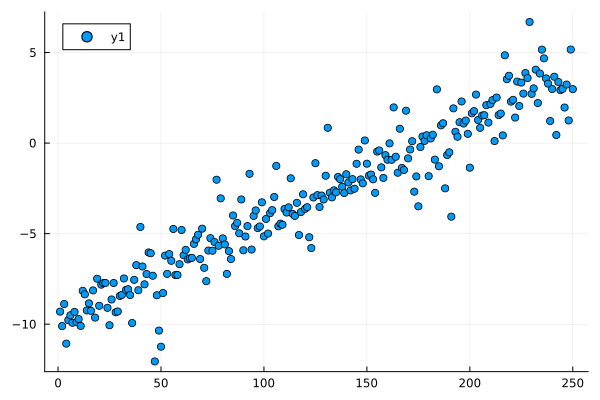

In [5]:
scatter(y)

### Running Chains

In [6]:
num_steps = 2000
num_chains = 8

# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), num_steps, num_chains)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Info: Found initial step size
└   ϵ = 0.00078125
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads):  44%|████████████▊                |  ETA: 0:00:59┌ Info: Found initial step size
└   ϵ = 0.00078125
┌ Info: Found initial step size
└   ϵ = 0.00078125
Sampling (4 threads):  50%|██████████████▌              |  ETA: 0:00:57┌ Info: Found initial step size
└   ϵ = 0.00078125
Sampling (4 threads):  52%|███████████████▎             |  ETA: 0:00:52┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:02:04


Chains MCMC chain (2000×250×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30], y[31], y[32], y[33], y[34], y[35], y[36], y[37], y[38], y[39], y[40], y[41], y[42], y[43], y[44], y[45], y[46], y[47], y[48], y[49], y[50], y[51], y[52], y[53], y[54], y[55], y[56], y[57], y[58], y[59], y[60], y[61], y[62], y[63], y[64], y[65], y[66], y[67], y[68], y[69], y[70], y[71], y[72], y[73], y[74], y[75], y[76], y[77], y[78], y[79], y[80], y[81], y[82], y[83], y[84], y[85], y[86], y[87], y[88], y[89], y[90], y[91], y[92], y[93], y[94], y[95], y[96], y[97], y[98], y[99], y[100], y[101], y[102], y[103], y[104], y[105], y[106], y[107], y[108], y[109], y[110], y[111], y[112], y[113], y[114], y[115], y[116], y[117], y[118], y[119], y[120], y

### Ethan's Manual LOO-PIT

In [7]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples

S_pd = PDMat(Cholesky(SL))

250×250 PDMat{Float64, Matrix{Float64}}:
  0.306031      0.000524969   0.0214048    …  -0.00201739  -0.0405174
  0.000524969   0.30238      -0.0199308       -0.0248133    0.0611419
  0.0214048    -0.0199308     0.774413         0.0069836   -0.0886018
  0.00792558   -0.040338     -0.0789993        0.0320866   -0.0202541
  0.00631835    0.00231243   -0.024014        -0.00446768   0.0536257
 -0.000695269  -0.000603941  -0.000319996  …  -0.00251502  -0.0300127
  0.0037331    -0.0385822    -0.0345929        0.0207845    0.0612133
  0.00163932    0.000293194   0.00190496       0.00814882   0.00720814
  0.0444832    -0.0509096     0.0367891        0.0346404   -0.0789475
  0.0195966     0.00233195   -0.0195871        0.0274618    0.0391452
  0.00754799   -0.0118603     0.0273662    …  -0.00457955  -0.277901
  0.0326152    -0.00148078    0.0470691       -0.0240015    0.156082
 -0.0192092     0.00974992    0.0682418        0.0417487    0.128266
  ⋮                                        ⋱       

### Log-Likelihoods

In [8]:
idata = from_mcmcchains(
        chns;
        posterior_predictive = y_pred,
        constant_data=(; x),
        observed_data=(; y),
        dims=(x=[:i], y=[:i], pred=[:i]),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > sample_stats
  > observed_data
  > constant_data

In [9]:
function inv_diag_cholesky(F::Cholesky)
    if F.uplo == 'U'
        U = inv(UpperTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachrow(U))
    else
        L = inv(LowerTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachcol(L))
    end
end

function pointwise_normal_loglikelihood!(
    log_like::AbstractArray,
    cov::AbstractMatrix,
    mean::AbstractVector,
    obs::AbstractVector,
)
    F = cholesky(cov)
    c = inv_diag_cholesky(F)
    g = F \ (obs - mean)
    @. log_like = (log(c) -g^2 / c - log(2π)) ./ 2
end

function pointwise_normal_loglikelihood(
    obs::AbstractVector, mean::AbstractArray, cov::AbstractArray
)
    num_sample_dims = ndims(mean) - 1
    @assert num_sample_dims ∈ (1, 2)
    @assert ndims(cov) == num_sample_dims + 2
    @assert length(obs) == 
        size(mean, num_sample_dims + 1) ==
        size(cov, num_sample_dims + 1) == 
        size(cov, num_sample_dims +2)

    cov_dims = ntuple(i -> i + num_sample_dims, 2)
    sample_dims = ntuple(identity, num_sample_dims)

    cov_axes = map(i -> axes(cov, i), cov_dims)
    sample_axes = map(i -> axes(cov, i), sample_dims)
    out_axes = (sample_axes..., cov_axes[1])

    log_like = similar(obs, Base.promote_eltype(obs, mean, cov), out_axes)
    foreach(
        pointwise_normal_loglikelihood!,
        eachslice(log_like; dims=sample_dims),
        eachslice(cov; dims=sample_dims),
        eachslice(mean; dims=sample_dims),
        Iterators.repeated(obs),
    )

    return log_like
end

pointwise_normal_loglikelihood (generic function with 1 method)

In [10]:
cov = repeat(reshape(Array(S_pd), 1, 1, n, n), num_steps, num_chains, 1, 1);

In [11]:
log_like = pointwise_normal_loglikelihood(
    idata.observed_data.y,
    µ_array,
    cov,
)

2000×8×250 Array{Float64, 3}:
[:, :, 1] =
 0.472249  0.498472  0.421996  0.423268  …  0.110703  0.506095  0.503033
 0.489474  0.382285  0.489556  0.437092     0.288161  0.430325  0.518589
 0.516382  0.419368  0.494424  0.434472     0.534324  0.31524   0.420768
 0.237366  0.49295   0.462889  0.54134      0.541642  0.467848  0.432174
 0.523315  0.409335  0.488662  0.541008     0.482363  0.505665  0.52625
 0.517554  0.411199  0.418314  0.483678  …  0.526233  0.396286  0.332485
 0.476338  0.539868  0.498477  0.509142     0.316174  0.425359  0.360632
 0.495533  0.275911  0.503801  0.481568     0.272043  0.445973  0.439127
 0.499653  0.423932  0.519006  0.488175     0.282613  0.536672  0.494167
 0.535803  0.472788  0.468531  0.350246     0.224738  0.542621  0.455499
 0.453656  0.349344  0.469065  0.528841  …  0.429846  0.541197  0.473831
 0.362522  0.35505   0.511418  0.533526     0.53984   0.382968  0.469
 0.504692  0.335046  0.487596  0.484956     0.539887  0.404881  0.448007
 ⋮           

In [12]:
idata = merge(
    idata,
    InferenceData(; log_likelihood = namedtuple_to_dataset((; y = log_like))),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > log_likelihood
  > sample_stats
  > observed_data
  > constant_data

### PSIS (Pareto Smoothed Importance Sampling)

In [13]:
psis_result = Vector{PSISResult{Float64, Vector{Float64}, Float64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, n);

In [14]:
for i in 1:n
    log_like_all_chains = vec(idata.log_likelihood[:,:,i][:y])
    like = LogExpFunctions.softmax(log_like_all_chains; dims=(1, 2))
    reff = MCMCDiagnosticTools.ess(like; kind=:basic, split_chains=1, relative=true)
    psis_result[i] = psis(-log_like_all_chains, reff)
end

In [15]:
log_weights = Array{Float64, 3}(undef, num_steps, num_chains, n)

for i in 1:n
    log_weights_local = psis_result[i].log_weights
    for j in 1:num_chains
        for k in 1:num_steps
            log_weights[k,j,i] = log_weights_local[(j-1)* num_steps + k]
        end
    end
end
log_weights

2000×8×250 Array{Float64, 3}:
[:, :, 1] =
 -9.72267  -9.74889  -9.67242  -9.67369  …  -9.36558  -9.75651  -9.75345
 -9.73989  -9.63271  -9.73998  -9.68751     -9.53858  -9.68074  -9.76901
 -9.7668   -9.66979  -9.74484  -9.68489     -9.78474  -9.56566  -9.67119
 -9.48779  -9.74337  -9.71331  -9.79176     -9.79206  -9.71827  -9.68259
 -9.77373  -9.65975  -9.73908  -9.79143     -9.73278  -9.75608  -9.77667
 -9.76797  -9.66162  -9.66873  -9.7341   …  -9.77665  -9.64671  -9.58291
 -9.72676  -9.79029  -9.7489   -9.75956     -9.56659  -9.67578  -9.61105
 -9.74595  -9.52633  -9.75422  -9.73199     -9.52246  -9.69639  -9.68955
 -9.75007  -9.67435  -9.76943  -9.73859     -9.53303  -9.78709  -9.74459
 -9.78622  -9.72321  -9.71895  -9.60067     -9.47516  -9.79304  -9.70592
 -9.70408  -9.59976  -9.71948  -9.77926  …  -9.68027  -9.79162  -9.72425
 -9.61294  -9.60547  -9.76184  -9.78395     -9.79026  -9.63339  -9.71942
 -9.75511  -9.58547  -9.73802  -9.73538     -9.79031  -9.6553   -9.69843
  ⋮      

In [16]:
pareto_shapes = Vector{Float64}(undef, n)

for i in 1:n
    pareto_shapes[i] = psis_result[i].pareto_shape
end

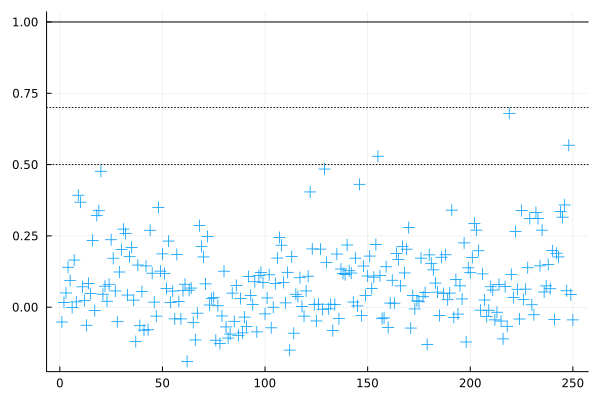

In [17]:
scatter(pareto_shapes; marker =:+, markersize=6, legend = false, linewidth=2)
hline!([0.5,0.7], linestyle=:dot, color =:black)
hline!([1.0], linestyle=:solid, color=:black)

### (PIT) Probability Integral Transfrom

In [18]:
draws = Vector{Vector{Float64}}(undef, num_steps*num_chains)

for i in 1:num_steps
    for j in 1:num_chains
        new_µ = vec(µ_array[i,j,:])
        dist = MvNormal(new_µ, S_pd)
        draws[(i-1)*num_chains + j] = rand(dist)
    end
end

In [19]:
comparison_values = Array{Float64}(undef, n, num_steps)

for j in 1:num_steps
    draw = draws[j]
    data = y

    for i in 1:n
        if draw[i] < data[i]
            comparison_values[i,j] = 1
        else
            comparison_values[i,j] = 0
        end
    end
end

In [20]:
PIT_Values = Vector{Float64}(undef, n)
for i in 1:n
    sum = 0
    for j in 1:num_steps
        sum += comparison_values[i,j]
    end

    PIT_Values[i] = sum / num_steps
end

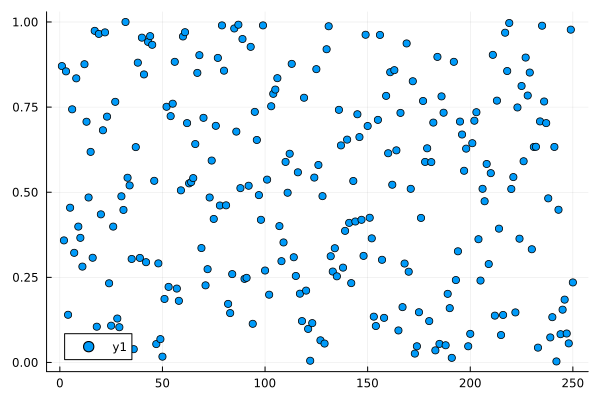

In [21]:
scatter(PIT_Values)

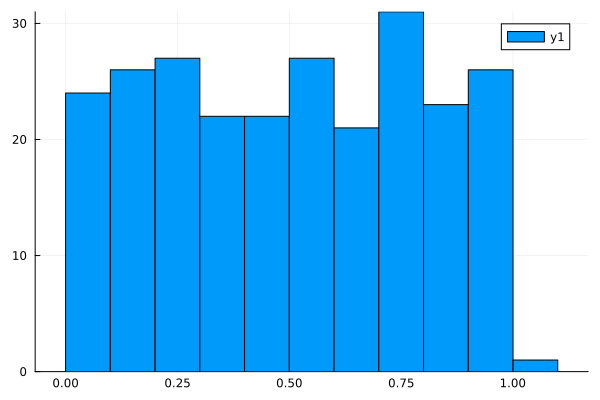

In [22]:
histogram(PIT_Values, bins = 10)

### Comparison of first data point observation and draws

In [23]:
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

2000×8×250 Array{Float64, 3}:
[:, :, 1] =
  -9.6866    -9.35327  -10.5649   …   -9.23556  -10.3247    -9.94593
 -10.272    -10.6393    -9.89754      -9.12196   -9.92718  -10.2539
  -9.39778   -9.90799  -10.0385       -9.56598  -10.8211    -9.17172
  -9.6205   -10.2681   -10.049        -8.9976   -10.0562   -10.007
 -11.1013   -10.4085    -9.44148      -9.97656  -10.347     -8.83838
  -9.59179  -10.3023   -10.3257   …  -10.307     -9.94129  -10.6801
 -10.0308   -10.3471    -9.68771     -10.0317    -9.48135   -9.96689
  -9.36175  -10.3642   -10.4171       -8.92003   -9.20766   -8.88372
  -9.37058   -9.49442  -10.6057       -9.78488   -9.42443  -10.0143
  -9.72982  -10.8066    -9.44054      -9.04024  -10.8445   -10.4517
  -9.67256  -10.1126   -10.356    …   -9.79591  -11.2389    -9.67936
  -9.95804  -10.5841    -9.27548      -9.98311  -10.2064   -10.3588
 -10.3472    -9.2768    -9.7866      -10.1186   -10.1638   -10.8257
   ⋮                              ⋱    ⋮                   
  -9.6939

In [24]:
y_1_array = []
for i in 1:8
    y_1_array = append!(y_1_array, y_pred_array[:,i,1])
end

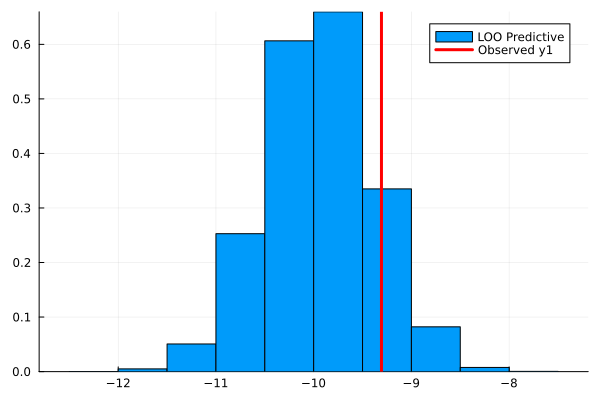

In [25]:
histogram(y_1_array, normalize=:pdf, bins = 20, label="LOO Predictive")
vline!([y[1]], color=:red, linewidth=3, label = "Observed y1")

In [26]:
ks_test_ethan = ExactOneSampleKSTest(PIT_Values, Uniform(0, 1))
pvalue(ks_test_ethan)

0.9730856777604221